In [1]:
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
import pandas as pd
import numpy as np
from src.preprocessing import scale_features, add_outlier_flags, target_feature_split, one_hot_encoding
from src.feature_engineering import create_vocal_instrumental_ratio, create_energy_rhythm_interaction, create_moodscore_bins
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import joblib

In [2]:
# Input Data
df_train = pd.read_csv("../data/raw/train.csv")
df_test = pd.read_csv("../data/raw/test.csv")
df_sample_submission = pd.read_csv("../data/raw/sample_submission.csv")


In [3]:
#preprocessing
df_train, scaler = scale_features(df_train, ['AudioLoudness','TrackDurationMs'])
df_train, _ = add_outlier_flags(df_train, ['RhythmScore','AudioLoudness','VocalContent','AcousticQuality','InstrumentalScore','LivePerformanceLikelihood','TrackDurationMs'])

df_test, _ = scale_features(df_test,  ['AudioLoudness','TrackDurationMs'], scaler)
df_test, _ = add_outlier_flags(df_test, ['RhythmScore','AudioLoudness','VocalContent','AcousticQuality','InstrumentalScore','LivePerformanceLikelihood','TrackDurationMs'])

In [4]:
#feature engineering
df_train = create_vocal_instrumental_ratio(df_train)
df_train = create_energy_rhythm_interaction(df_train)
df_train = create_moodscore_bins(df_train)

df_test = create_vocal_instrumental_ratio(df_test)
df_test = create_energy_rhythm_interaction(df_test)
df_test = create_moodscore_bins(df_test)

In [5]:
# in case i use linear regression
df_train, encoder = one_hot_encoding(df_train, 'MoodScore_bins')
df_test, _ = one_hot_encoding(df_test, 'MoodScore_bins', encoder)

In [6]:
#Definition of X and y
X_train, y_train = target_feature_split(df=df_train, target="BeatsPerMinute", exclude_cols=['id'])
X_test, y_test = target_feature_split(df=df_test, exclude_cols=['id'])

In [7]:
RANDOM_STATE = 42
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
version = "baseline"

In [8]:
""" models = {
    "dummy": DummyRegressor(strategy="mean"),
    "ridge": Ridge(random_state=RANDOM_STATE),
    "rf": RandomForestRegressor(max_depth=12,
                                min_samples_leaf=5, n_jobs=-1,
                                random_state=RANDOM_STATE),
    "lgbm": LGBMRegressor(n_jobs=-1, random_state=RANDOM_STATE)
}

oof = {name: np.zeros(len(X_train)) for name in models.keys()} """

' models = {\n    "dummy": DummyRegressor(strategy="mean"),\n    "ridge": Ridge(random_state=RANDOM_STATE),\n    "rf": RandomForestRegressor(max_depth=12,\n                                min_samples_leaf=5, n_jobs=-1,\n                                random_state=RANDOM_STATE),\n    "lgbm": LGBMRegressor(n_jobs=-1, random_state=RANDOM_STATE)\n}\n\noof = {name: np.zeros(len(X_train)) for name in models.keys()} '

In [11]:
X_train.to_parquet("../data/processed/X_train_baseline.parquet", index=False)
y_train.to_frame("BeatsPerMinute").to_parquet("../data/processed/y_train_baseline.parquet", index=False)
X_test.to_parquet("../data/processed/X_test_baseline.parquet", index=False)
#y_test.to_frame("BeatsPerMinute").to_parquet("../data/processed/y_test_baseline.parquet", index=False)

In [9]:
train_models = {
    "dummy": DummyRegressor(strategy="mean"),
    "ridge": Ridge(random_state=RANDOM_STATE),
    "rf": RandomForestRegressor(max_depth=12,min_samples_leaf=5, n_jobs=-1,random_state=RANDOM_STATE),
    "lgbm": LGBMRegressor(n_jobs=-1, random_state=RANDOM_STATE)
}

oof = {name: np.zeros(len(X_train)) for name in train_models.keys()}

models = {}

for model in list(train_models.keys()):
    if os.path.exists(f"../models/{model}_{version}_seed{RANDOM_STATE}.pkl") and os.path.exists(f"../data/processed/{model}_oof_{version}_seed{RANDOM_STATE}.npy"):
        models[f'{model}'] = joblib.load(f"../models/{model}_{version}_seed{RANDOM_STATE}.pkl")
        oof[f'{model}'] = np.load(f"../data/processed/{model}_oof_{version}_seed{RANDOM_STATE}.npy")
        del train_models[f'{model}']

In [10]:
oof


{'dummy': array([0., 0., 0., ..., 0., 0., 0.]),
 'ridge': array([0., 0., 0., ..., 0., 0., 0.]),
 'rf': array([0., 0., 0., ..., 0., 0., 0.]),
 'lgbm': array([0., 0., 0., ..., 0., 0., 0.])}

In [11]:
""" for i, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Validation:  index={val_index}")
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    print(f"Dummy:")
    models['dummy'].fit(X_tr, y_tr)
    oof['dummy'][val_index] = models['dummy'].predict(X_val)

    print(f"Ridge:")
    models['ridge'].fit(X_tr, y_tr)
    oof['ridge'][val_index] = models['ridge'].predict(X_val)

    print(f"Random Forest:")
    models['rf'].fit(X_tr, y_tr)
    oof['rf'][val_index] = models['rf'].predict(X_val)

    print(f"LGBM:")
    models['lgbm'].fit(X_tr, y_tr)
    oof['lgbm'][val_index] = models['lgbm'].predict(X_val) """

' for i, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):\n    print(f"Fold {i}:")\n    print(f"  Train: index={train_index}")\n    print(f"  Validation:  index={val_index}")\n    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]\n    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]\n\n    print(f"Dummy:")\n    models[\'dummy\'].fit(X_tr, y_tr)\n    oof[\'dummy\'][val_index] = models[\'dummy\'].predict(X_val)\n\n    print(f"Ridge:")\n    models[\'ridge\'].fit(X_tr, y_tr)\n    oof[\'ridge\'][val_index] = models[\'ridge\'].predict(X_val)\n\n    print(f"Random Forest:")\n    models[\'rf\'].fit(X_tr, y_tr)\n    oof[\'rf\'][val_index] = models[\'rf\'].predict(X_val)\n\n    print(f"LGBM:")\n    models[\'lgbm\'].fit(X_tr, y_tr)\n    oof[\'lgbm\'][val_index] = models[\'lgbm\'].predict(X_val) '

In [12]:
for i, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Validation:  index={val_index}")
    X_tr, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_tr, y_val = y_train.iloc[train_index], y_train.iloc[val_index]

    for model in train_models.keys():
        print(f"Fitting: {model}")
        train_models[f"{model}"].fit(X_tr, y_tr)
        oof[f"{model}"][val_index] = train_models[f"{model}"].predict(X_val)

for model in train_models.keys():
    print(f"Dumping and saving oof: {model}")
    joblib.dump(train_models[model], f"../models/{model}_{version}_seed{RANDOM_STATE}.pkl")
    np.save(f"../data/processed/{model}_oof_{version}_seed{RANDOM_STATE}.npy", oof[f'{model}'])
    models[f"{model}"] = train_models[f"{model}"]

Fold 0:
  Train: index=[     0      1      3 ... 524159 524160 524162]
  Validation:  index=[     2      6      7 ... 524146 524161 524163]
Fitting: dummy
Fitting: ridge
Fitting: rf
Fitting: lgbm
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.410599 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2821
[LightGBM] [Info] Number of data points in the train set: 419331, number of used features: 19
[LightGBM] [Info] Start training from score 119.056554
Fold 1:
  Train: index=[     1      2      3 ... 524160 524161 524163]
  Validation:  index=[     0     11     16 ... 524153 524159 524162]
Fitting: dummy
Fitting: ridge
Fitting: rf
Fitting: lgbm
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034270 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2821
[Li

In [13]:
rmses = {}
for name, preds in oof.items():
    print(name, "RMSE:", root_mean_squared_error(y_train, preds), "MAE:", mean_absolute_error(y_train, preds))
    rmses

dummy RMSE: 26.468078417587844 MAE: 21.19987341149104
ridge RMSE: 26.466341374596727 MAE: 21.19792095039579
rf RMSE: 26.465788481708344 MAE: 21.197653869516085
lgbm RMSE: 26.467350811600735 MAE: 21.198498087056862


#### Way to small of a difference between models.

In [14]:
models['rf'].feature_importances_

array([1.08207154e-01, 9.56962862e-02, 8.44282939e-02, 8.56717909e-02,
       5.85744187e-02, 9.97650645e-02, 7.97323472e-02, 1.25357118e-01,
       9.04350723e-02, 0.00000000e+00, 4.88917722e-05, 6.42063696e-05,
       1.30187166e-04, 6.05359677e-05, 0.00000000e+00, 8.04480254e-05,
       8.48881736e-02, 8.39708063e-02, 3.25155098e-04, 2.56405019e-03])

In [15]:
models['lgbm'].feature_importances_

array([283, 303, 279, 245, 185, 308, 320, 369, 289,   0,   1,   1,   1,
         0,   0,   1, 200, 208,   0,   7])

In [16]:
""" dict_importances = {}
for model in models.keys():
    print(model)
    perm = permutation_importance(models[model], X_train, y_train, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    importance_df = pd.DataFrame({"feature": X_train.columns, "perm_importance": perm["importances_mean"]})
    importance_df = importance_df.sort_values("perm_importance", ascending=False)
    dict_importances[model] = importance_df """

' dict_importances = {}\nfor model in models.keys():\n    print(model)\n    perm = permutation_importance(models[model], X_train, y_train, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)\n    importance_df = pd.DataFrame({"feature": X_train.columns, "perm_importance": perm["importances_mean"]})\n    importance_df = importance_df.sort_values("perm_importance", ascending=False)\n    dict_importances[model] = importance_df '

In [17]:
dict_importances = {}
for model in models.keys():
    print(model)
    _filepath = f"../data/processed/{model}_pi_{version}_seed{RANDOM_STATE}.parquet"
    if os.path.exists(_filepath):
        dict_importances[model] = pd.read_parquet(_filepath)
    else:
        perm = permutation_importance(models[model], X_train, y_train, scoring="neg_root_mean_squared_error", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
        importance_df = pd.DataFrame({"feature": X_train.columns, "perm_importance": perm["importances_mean"]})
        importance_df = importance_df.sort_values("perm_importance", ascending=False)
        dict_importances[model] = importance_df
        importance_df.to_parquet(_filepath,index=False)

dummy
ridge
rf
lgbm


In [18]:
dict_importances['dummy']

,feature,perm_importance
0,RhythmScore,0.0
1,AudioLoudness,0.0
18,MoodScore_bins_low,0.0
17,energy_rhythm_interaction,0.0
16,vocal_instrumental_ratio,0.0
15,is_outlier_TrackDurationMs,0.0
14,is_outlier_LivePerformanceLikelihood,0.0
13,is_outlier_InstrumentalScore,0.0
12,is_outlier_AcousticQuality,0.0
11,is_outlier_VocalContent,0.0


In [19]:
dict_importances['ridge']

,feature,perm_importance
6,MoodScore,6.646678e-03
18,MoodScore_bins_low,3.840736e-03
7,TrackDurationMs,1.687896e-03
0,RhythmScore,1.218151e-03
2,VocalContent,7.750130e-04
19,MoodScore_bins_medium,5.756219e-04
5,LivePerformanceLikelihood,3.923378e-04
1,AudioLoudness,1.669046e-04
15,is_outlier_TrackDurationMs,1.584642e-04
17,energy_rhythm_interaction,1.567702e-04


In [20]:
dict_importances['rf']

,feature,perm_importance
6,MoodScore,1.487987e-01
7,TrackDurationMs,1.314746e-01
0,RhythmScore,9.585416e-02
5,LivePerformanceLikelihood,7.409106e-02
8,Energy,7.068232e-02
2,VocalContent,6.973399e-02
1,AudioLoudness,5.597455e-02
17,energy_rhythm_interaction,5.363235e-02
3,AcousticQuality,5.091046e-02
16,vocal_instrumental_ratio,5.000142e-02


In [21]:
dict_importances['lgbm']

,feature,perm_importance
6,MoodScore,0.068187
7,TrackDurationMs,0.054663
8,Energy,0.044451
2,VocalContent,0.042100
0,RhythmScore,0.041125
5,LivePerformanceLikelihood,0.039270
17,energy_rhythm_interaction,0.036003
1,AudioLoudness,0.034528
3,AcousticQuality,0.033137
16,vocal_instrumental_ratio,0.026067


In [22]:
dict_error_by_bin = {}
for model in models.keys():
    df_resid = pd.DataFrame({"y_true": y_train, "y_pred": oof[model]})
    
    df_resid["BPM_bin"] = pd.qcut(df_resid["y_true"], q=5, labels=[f"Q1", "Q2", "Q3", "Q4", "Q5"])
    
    error_by_bin = df_resid.groupby("BPM_bin").apply(lambda d: root_mean_squared_error(d.y_true, d.y_pred))
    dict_error_by_bin[model] = error_by_bin

C:\Users\menez\AppData\Local\Temp\ipykernel_9116\959356576.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_bin = df_resid.groupby("BPM_bin").apply(lambda d: root_mean_squared_error(d.y_true, d.y_pred))
C:\Users\menez\AppData\Local\Temp\ipykernel_9116\959356576.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_by_bin = df_resid.groupby("BPM_bin").apply(lambda d: root_mean_squared_error(d.y_true, d.y_pred))
C:\Users\menez\AppData\Local\Temp\ipykernel_9116\959356576.py:7: FutureWarning: The defa

In [23]:
dict_error_by_bin

{'dummy': BPM_bin
 Q1    38.537388
 Q2    15.007049
 Q3     3.951164
 Q4    14.614545
 Q5    39.538506
 dtype: float64,
 'ridge': BPM_bin
 Q1    38.528707
 Q2    15.011208
 Q3     3.967620
 Q4    14.616610
 Q5    39.537165
 dtype: float64,
 'rf': BPM_bin
 Q1    38.501665
 Q2    15.031465
 Q3     4.073729
 Q4    14.638233
 Q5    39.535175
 dtype: float64,
 'lgbm': BPM_bin
 Q1    38.510559
 Q2    15.032779
 Q3     4.073727
 Q4    14.633230
 Q5    39.533093
 dtype: float64}

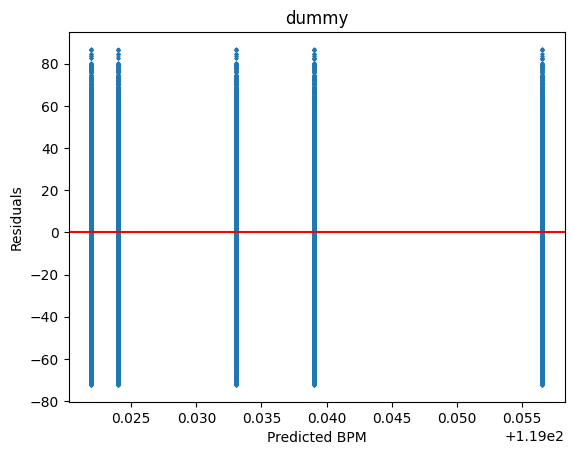

In [24]:
preds = oof["dummy"]  
resid = y_train - preds
plt.title("dummy")
plt.scatter(preds, resid, s=2)
plt.xlabel("Predicted BPM")
plt.ylabel("Residuals")
plt.axhline(0, color="red")
#it has 5 vertical lines because of the 5 folds, each one has a slightly different mean

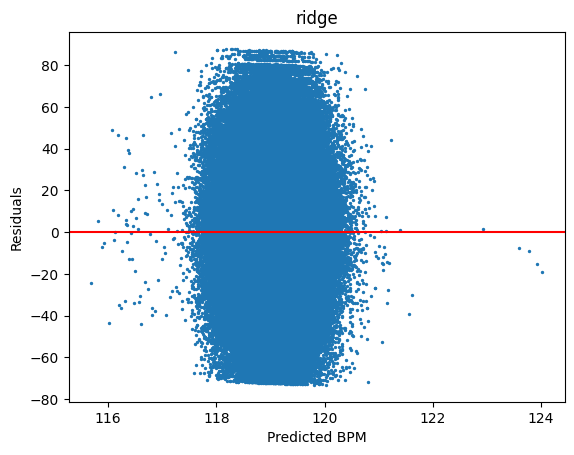

In [25]:
preds = oof["ridge"]  
resid = y_train - preds
plt.title("ridge")
plt.scatter(preds, resid, s=2)
plt.xlabel("Predicted BPM")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

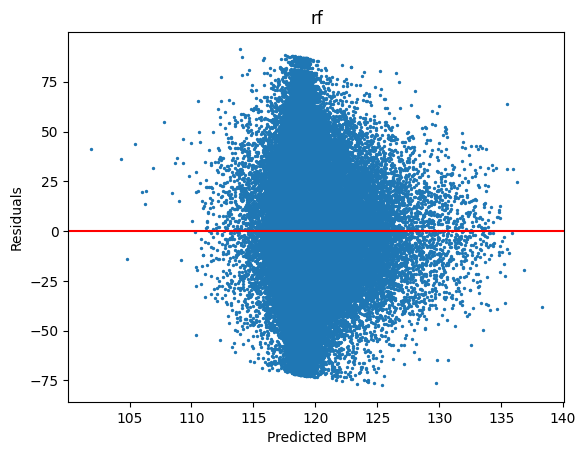

In [26]:
preds = oof["rf"]  
resid = y_train - preds
plt.title("rf")
plt.scatter(preds, resid, s=2)
plt.xlabel("Predicted BPM")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

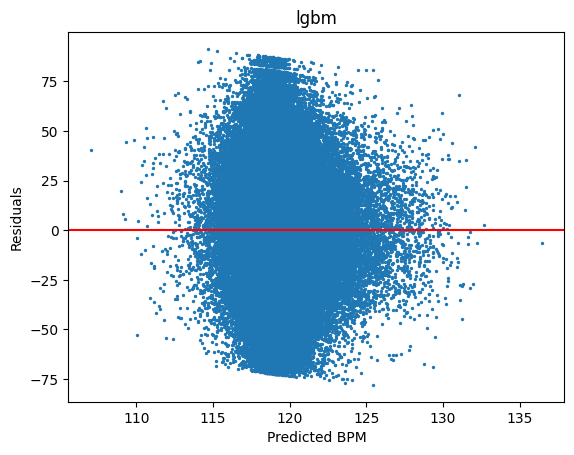

In [27]:
preds = oof["lgbm"]  
resid = y_train - preds
plt.title("lgbm")
plt.scatter(preds, resid, s=2)
plt.xlabel("Predicted BPM")
plt.ylabel("Residuals")
plt.axhline(0, color="red")

In [28]:
#First submission
y_test_pred = models['rf'].predict(X_test)
df_sample_submission['BeatsPerMinute'] = y_test_pred
df_sample_submission.to_csv("../results/baseline_submission.csv", index=False)